In [29]:
import numpy as np
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [37]:
# 1. Load the data
msft = r'\Users\Troy\Downloads\tchin-heston-volatility-option-pricer\src\data\msft_data.csv' 
df = pd.read_csv(msft)

# 2. Inspect data (separate statements with newlines instead of semicolons for readability)
print(df.head(10))
print(df.describe().T)

# 3. Separate features and target
target = 'Open'
X = df.drop(columns=target)
y = df[target]

# 4. Split data (20% test, 80% train)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Check shapes
print(X_test.shape, y_test.shape)


                        Date      Open      High       Low     Close  \
0  1986-03-13 00:00:00-05:00  0.053847  0.061765  0.053847  0.059125   
1  1986-03-14 00:00:00-05:00  0.059125  0.062293  0.059125  0.061237   
2  1986-03-17 00:00:00-05:00  0.061237  0.062821  0.061237  0.062293   
3  1986-03-18 00:00:00-05:00  0.062293  0.062821  0.060181  0.060709   
4  1986-03-19 00:00:00-05:00  0.060709  0.061237  0.059125  0.059653   
5  1986-03-20 00:00:00-05:00  0.059653  0.059653  0.057542  0.058070   
6  1986-03-21 00:00:00-05:00  0.058070  0.059125  0.055430  0.056486   
7  1986-03-24 00:00:00-05:00  0.056486  0.056486  0.054375  0.054902   
8  1986-03-25 00:00:00-05:00  0.054902  0.055958  0.054374  0.055958   
9  1986-03-26 00:00:00-05:00  0.055958  0.058070  0.055430  0.057542   

       Volume  Dividends  Stock Splits  
0  1031788800        0.0           0.0  
1   308160000        0.0           0.0  
2   133171200        0.0           0.0  
3    67766400        0.0           0.0  
4 

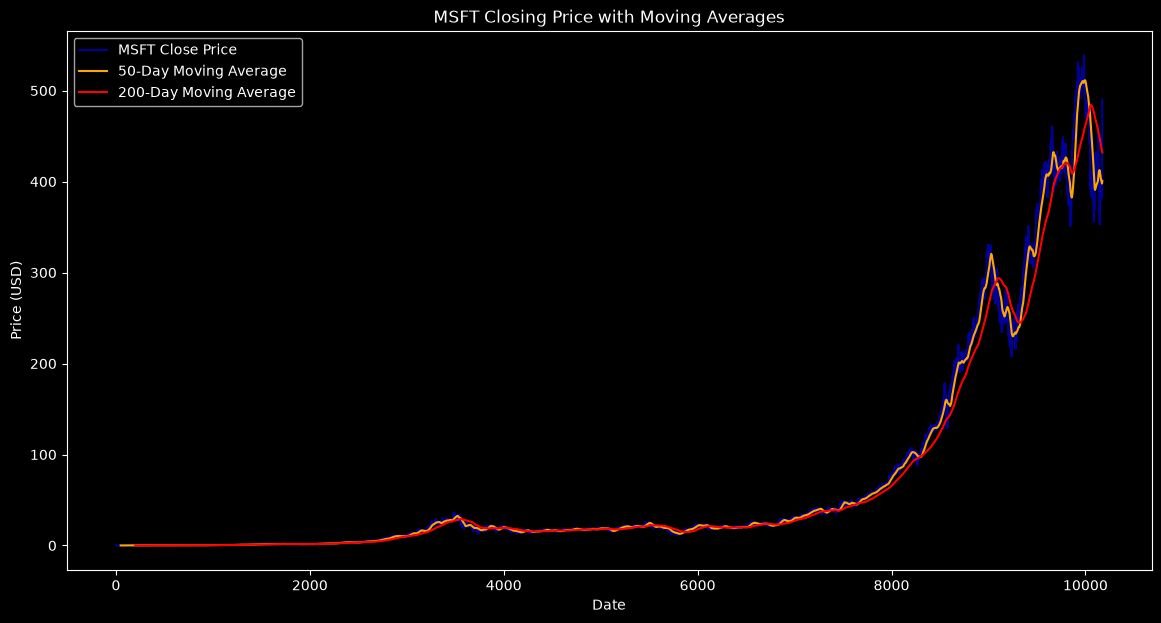

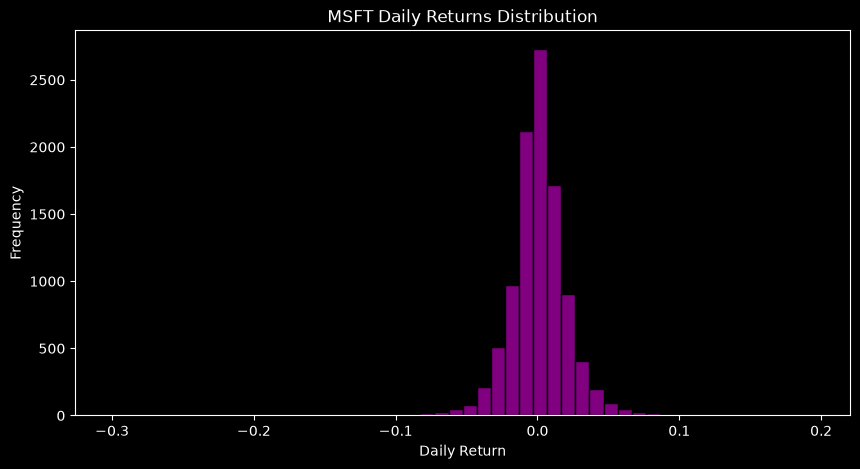

In [38]:
df.columns = df.columns.get_level_values(0)

# 2. Visualize Closing Price and Moving Averages
df['MA_50'] = df['Close'].rolling(window=50).mean() 
df['MA_200'] = df['Close'].rolling(window=200).mean() 


plt.style.use('dark_background')
plt.figure(figsize=(14, 7)) 
plt.plot(df['Close'], label='MSFT Close Price', color='blue', alpha=0.6) 
plt.plot(df['MA_50'], label='50-Day Moving Average', color='orange') 
plt.plot(df['MA_200'], label='200-Day Moving Average', color='red') 
plt.title('MSFT Closing Price with Moving Averages') 
plt.xlabel('Date') 
plt.ylabel('Price (USD)') 
plt.legend() 
plt.show() 

# 3. Analyze Daily Returns 
df['Daily_Return'] = df['Close'].pct_change() 

plt.figure(figsize=(10, 5)) 
plt.hist(df['Daily_Return'].dropna(), bins=50, color='purple', edgecolor='black') 
plt.title('MSFT Daily Returns Distribution') 
plt.xlabel('Daily Return') 
plt.ylabel('Frequency') 
plt.show()
